# 05 · GIS Extraction

[Index](./00_index.ipynb) · [← Previous](./04_classification.ipynb) · [Next →](./06_validation.ipynb)

The IFC sample model `AC20-FZK-Haus.ifc` is provided as part of the KIT IFC example dataset, developed by the Institute for Automation and Applied Informatics (IAI) at Karlsruhe Institute of Technology (KIT). It is distributed for unrestricted use and commonly referenced in IFC tutorials, including IfcOpenShell documentation and sample workflows.

This notebook is standalone: it re-downloads and re-opens the model so it can run on its own in Colab, independent of the other notebooks in this portfolio.

In [1]:
!pip install -q ifcopenshell numpy pandas shapely geopandas matplotlib requests

In [2]:
import ifcopenshell
import ifcopenshell.geom
import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import shapely.geometry as geom
from shapely.geometry import MultiPoint
import geopandas as gpd

In [3]:
# Load the sample IFC model
import ifcopenshell
import requests

r = requests.get("https://www.ifcwiki.org/images/e/e3/AC20-FZK-Haus.ifc")
with open("model.ifc", "w") as f:
    f.write(r.text)

model = ifcopenshell.open("model.ifc")

print("Schema:", model.schema)
print("Walls:", len(model.by_type("IfcWall")))

Schema: IFC4
Walls: 13


In [4]:
# Shared categorical palette (fixed order — never reassign per-filter).
# Colorblind-validated: blue, orange, aqua, yellow, magenta, green, violet, red.
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQUENTIAL_BLUE = "#2a78d6"

In [5]:
settings = ifcopenshell.geom.settings()
settings.set(settings.USE_WORLD_COORDS, True)

## GIS extraction
<a id="gis-extraction"></a>

In [6]:
# Footprints
def element_footprint(element, settings):
    shape = ifcopenshell.geom.create_shape(settings, element)
    verts = np.array(shape.geometry.verts).reshape(-1, 3)
    xy = verts[:, :2]
    return MultiPoint(xy).convex_hull


rows = []
target_classes = ["IfcWall", "IfcSlab", "IfcDoor", "IfcWindow", "IfcColumn"]

for cls in target_classes:
    for e in model.by_type(cls):
        try:
            footprint = element_footprint(e, settings)
            rows.append({
                "GlobalId": e.GlobalId,
                "Class": e.is_a(),
                "Name": e.Name,
                "PredefinedType": getattr(e, "PredefinedType", None),
                "Area_2D": footprint.area,
                "Length_2D": footprint.length,
                "geometry": footprint
            })
        except Exception as err:
            print("Skipped:", e.is_a(), e.Name, err)

df_footprints = pd.DataFrame(rows)
df_footprints.head()

,GlobalId,Class,Name,PredefinedType,Area_2D,Length_2D,geometry
0,2XPyKWY018sA1ygZKgQPtU,IfcWallStandardCase,Wand-Int-ERDG-4,NaN,1.0008,8.919411,"POLYGON ((7.41 4.01, 7.65 4.25, 11.7 4.25, 11...."
1,3PfS__Y_DBAfq5naM6zD2Z,IfcWallStandardCase,Wand-Int-ERDG-2,NaN,1.3368,11.719411,"POLYGON ((7.41 4.01, 7.41 9.7, 7.65 9.7, 7.65 ..."
2,2ptk1k7qn8_Qk22vjh$0DE,IfcWallStandardCase,Wand-Int-ERDG-1,NaN,0.8904,7.900000,"POLYGON ((3.8 5.99, 3.8 9.7, 4.04 9.7, 4.04 5...."
3,3jjW3rL656ex34Gws22EfM,IfcWallStandardCase,Wand-Int-ERDG-3,NaN,1.7064,14.700000,"POLYGON ((0.3 5.75, 0.3 5.99, 7.41 5.99, 7.41 ..."
4,1$wmdwWPjDYuku_ghVkynE,IfcWallStandardCase,Wand-Int-ERDG-5,NaN,0.8400,7.480000,"POLYGON ((0.3 4.01, 0.3 4.25, 3.8 4.25, 3.8 4...."


In [7]:
# GeoDataFrame (Georeferenced)
gdf_footprints = gpd.GeoDataFrame(
    df_footprints,
    geometry="geometry",
    crs=None  # IFC local coordinates unless georeferenced
)

gdf_footprints.head()

,GlobalId,Class,Name,PredefinedType,Area_2D,Length_2D,geometry
0,2XPyKWY018sA1ygZKgQPtU,IfcWallStandardCase,Wand-Int-ERDG-4,NaN,1.0008,8.919411,"POLYGON ((7.41 4.01, 7.65 4.25, 11.7 4.25, 11...."
1,3PfS__Y_DBAfq5naM6zD2Z,IfcWallStandardCase,Wand-Int-ERDG-2,NaN,1.3368,11.719411,"POLYGON ((7.41 4.01, 7.41 9.7, 7.65 9.7, 7.65 ..."
2,2ptk1k7qn8_Qk22vjh$0DE,IfcWallStandardCase,Wand-Int-ERDG-1,NaN,0.8904,7.900000,"POLYGON ((3.8 5.99, 3.8 9.7, 4.04 9.7, 4.04 5...."
3,3jjW3rL656ex34Gws22EfM,IfcWallStandardCase,Wand-Int-ERDG-3,NaN,1.7064,14.700000,"POLYGON ((0.3 5.75, 0.3 5.99, 7.41 5.99, 7.41 ..."
4,1$wmdwWPjDYuku_ghVkynE,IfcWallStandardCase,Wand-Int-ERDG-5,NaN,0.8400,7.480000,"POLYGON ((0.3 4.01, 0.3 4.25, 3.8 4.25, 3.8 4...."


### Display

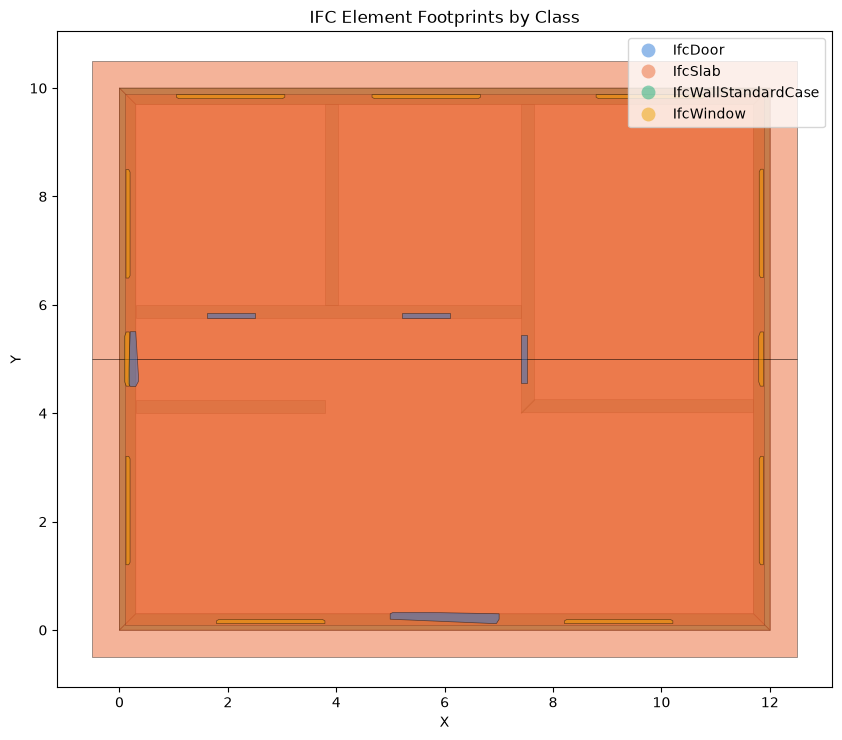

In [8]:
# Colors follow the shared categorical palette, in a fixed order per class,
# instead of matplotlib's default (unvalidated) qualitative colormap.
class_order = sorted(gdf_footprints["Class"].unique())
cmap = ListedColormap(CATEGORICAL[: len(class_order)])

ax = gdf_footprints.plot(
    figsize=(10, 10),
    column="Class",
    categories=class_order,
    cmap=cmap,
    legend=True,
    alpha=0.5,
    edgecolor="black",
    linewidth=0.5
)

ax.set_title("IFC Element Footprints by Class")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_aspect("equal")
plt.show()

In [9]:
# Get IFC site location
site = model.by_type("IfcSite")[0]

print("RefLatitude:", site.RefLatitude)
print("RefLongitude:", site.RefLongitude)

RefLatitude: (49, 6, 1, 566000)
RefLongitude: (8, 26, 11, 540400)


In [10]:
# Convert coordinates to decimals
def ifc_dms_to_decimal(dms):
    """IFC stores lat/lon as (degrees, minutes, seconds, millionths_of_seconds)."""
    if dms is None:
        return None

    deg = dms[0]
    minutes = dms[1] if len(dms) > 1 else 0
    seconds = dms[2] if len(dms) > 2 else 0
    millionths = dms[3] if len(dms) > 3 else 0

    sign = -1 if deg < 0 else 1
    return sign * (abs(deg) + minutes / 60 + (seconds + millionths / 1_000_000) / 3600)


lat = ifc_dms_to_decimal(site.RefLatitude)
lon = ifc_dms_to_decimal(site.RefLongitude)

print("Latitude:", lat)
print("Longitude:", lon)

Latitude: 49.100435000000004
Longitude: 8.436539


In [11]:
# Approximate georeferencing of Geometry
gdf_geo = gdf_footprints.copy()

gdf_geo["geometry"] = gdf_geo.geometry.translate(xoff=lon, yoff=lat)
gdf_geo = gdf_geo.set_crs("EPSG:4326", allow_override=True)

gdf_geo.head()

,GlobalId,Class,Name,PredefinedType,Area_2D,Length_2D,geometry
0,2XPyKWY018sA1ygZKgQPtU,IfcWallStandardCase,Wand-Int-ERDG-4,NaN,1.0008,8.919411,"POLYGON ((15.84654 53.11044, 16.08654 53.35044..."
1,3PfS__Y_DBAfq5naM6zD2Z,IfcWallStandardCase,Wand-Int-ERDG-2,NaN,1.3368,11.719411,"POLYGON ((15.84654 53.11044, 15.84654 58.80044..."
2,2ptk1k7qn8_Qk22vjh$0DE,IfcWallStandardCase,Wand-Int-ERDG-1,NaN,0.8904,7.900000,"POLYGON ((12.23654 55.09044, 12.23654 58.80044..."
3,3jjW3rL656ex34Gws22EfM,IfcWallStandardCase,Wand-Int-ERDG-3,NaN,1.7064,14.700000,"POLYGON ((8.73654 54.85044, 8.73654 55.09044, ..."
4,1$wmdwWPjDYuku_ghVkynE,IfcWallStandardCase,Wand-Int-ERDG-5,NaN,0.8400,7.480000,"POLYGON ((8.73654 53.11044, 8.73654 53.35044, ..."


In [12]:
# Export GeoJSON File — Colab only triggers a browser download; the file is
# saved to disk either way.
gdf_geo.to_file("ifc_footprints_georeferenced.geojson", driver="GeoJSON")

try:
    from google.colab import files
    files.download("ifc_footprints_georeferenced.geojson")
except ImportError:
    import os
    print("Not running in Colab — file saved locally instead:")
    print(" -", os.path.abspath("ifc_footprints_georeferenced.geojson"))

Not running in Colab — file saved locally instead:
 - C:\Users\ReDI\Downloads\Claude Fun\ifc_analysis_portfolio\ifc_footprints_georeferenced.geojson
